In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "rohanbhuin"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
#else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/rohanbhuin/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

**Answer:** The objective of this experiment is to determine which breakfast burrito ingredient combination leads to the highest customer rating. Specifically, the experiment investigates whether the type of protein, salsa level, potatoes option, and their possible interactions affect how residents rate the burritos on a 1 to 10 scale. The goal is to use these results to identify the best burrito combination for the menu while minimizing food and cost waste.

2. State the outcome variable and how it was measured.

**Answer:** The outcome variable is the customer **satisfaction rating** of the breakfast burrito, measured on a scale from 1 to 10. While this is technically an ordinal rating scale, for this analysis it is being treated as a quantitative, continuous variable.

3. State the independent variables. What lurking variables may be present?

**Answer:** **Independent Variables:**

* **Protein** (3 levels): Bacon, Sausage, Chorizo
* **Salsa** (2 levels): Mild, Hot
* **Potatoes** (2 levels): Yes, No

These are all categorical variables.

**Lurking Variables:**

* Participant's personal food preferences
* Hunger level at the time of tasting
* Individual spice tolerance levels
* Dietary/Religious restrictions (Vegan, Only eats specific meat, etc.)
* Variation in burrito preparation, such as portion size, temperature, or ingredient freshness

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

**Answer:** A full factorial design is preferred here because the number of treatment combinations, i.e. 3 x 2 x 2 = 12, is manageable, so we can test **all possible combinations** of Protein, Salsa, and Potatoes. This allows us to estimate both **main effects and interaction effects**, which is important because the rating may depend on how the ingredients work together.

A $2^k$ fractional factorial design would use fewer runs, but it may introduce **confounding/aliasing**, making it harder to separate the true effects. Also, since Protein has three levels, a simple $2^k$ design would not directly represent the full structure of this experiment without removing or collapsing a protein level.

5. State all sets of statistical hypotheses.

**Answer:**
* Main effects:

$$
H_{0,\text{Protein}}: \alpha_i = 0 \text{ for all } i
$$

$$
H_{1,\text{Protein}}: \alpha_i \ne 0 \text{ for at least one } i
$$

$$
H_{0,\text{Salsa}}: \beta_j = 0 \text{ for all } j
$$

$$
H_{1,\text{Salsa}}: \beta_j \ne 0 \text{ for at least one } j
$$

$$
H_{0,\text{Potatoes}}: \gamma_k = 0 \text{ for all } k
$$

$$
H_{1,\text{Potatoes}}: \gamma_k \ne 0 \text{ for at least one } k
$$

* Two-way interactions:

$$
H_{0,\text{Protein}\times\text{Salsa}}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j
$$

$$
H_{1,\text{Protein}\times\text{Salsa}}: (\alpha\beta)_{ij} \ne 0 \text{ for at least one } i,j
$$

$$
H_{0,\text{Protein}\times\text{Potatoes}}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k
$$

$$
H_{1,\text{Protein}\times\text{Potatoes}}: (\alpha\gamma)_{ik} \ne 0 \text{ for at least one } i,k
$$

$$
H_{0,\text{Salsa}\times\text{Potatoes}}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k
$$

$$
H_{1,\text{Salsa}\times\text{Potatoes}}: (\beta\gamma)_{jk} \ne 0 \text{ for at least one } j,k
$$

* Three-way interaction:

$$
H_{0,\text{Protein}\times\text{Salsa}\times\text{Potatoes}}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k
$$

$$
H_{1,\text{Protein}\times\text{Salsa}\times\text{Potatoes}}: (\alpha\beta\gamma)_{ijk} \ne 0 \text{ for at least one } i,j,k
$$

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

**Answer:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       120 non-null    object 
 1   Salsa         120 non-null    object 
 2   Potatoes      120 non-null    object 
 3   Satisfaction  120 non-null    float64
dtypes: float64(1), object(3)
memory usage: 3.9+ KB
None
Protein Stats:
            mean       std
Protein                  
Bacon    6.8500  0.928467
Chorizo  7.0075  1.167374
Sausage  5.7725  1.052710

Salsa Stats:
            mean       std
Salsa                    
Hot    6.070000  1.116031
Mild   7.016667  1.055762

Potatoes Stats:
               mean       std
Potatoes                    
No        6.335000  1.227071
Yes       6.751667  1.105378

Protein and Salsa Stats:
                 mean       std
Protein Salsa                 
Bacon   Hot    6.450  0.870269
        Mild   7.250  0.821744
Chorizo Hot    6.470  1.090196


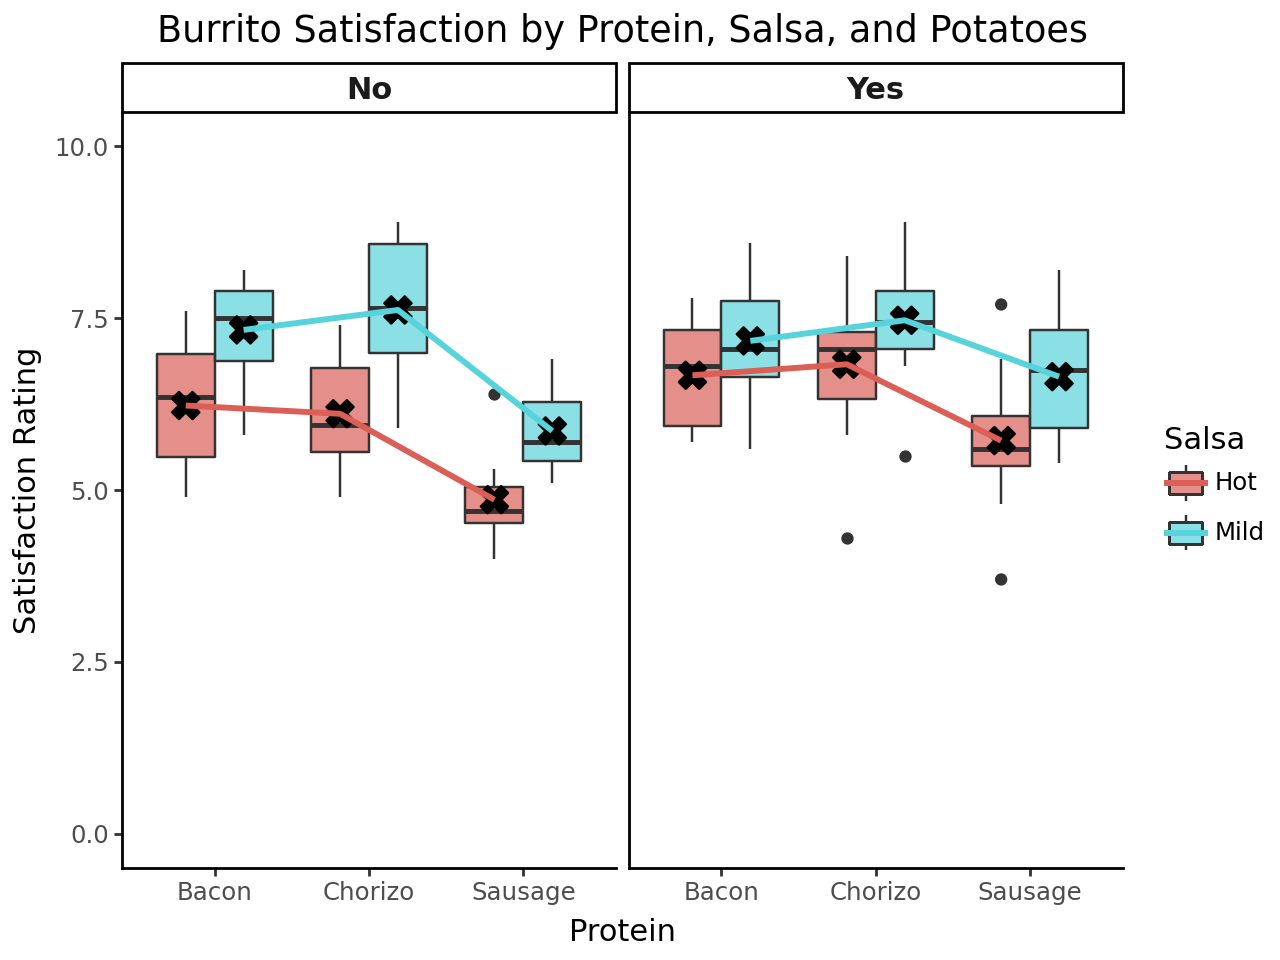

In [3]:
## Question 6 Code ##

## Import necessary libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from plotnine import *
from plotnine.positions import position_dodge

## Read the data ##
burritos = pd.read_excel("Busters Burritos.xlsx")

## Data Integrity Check ##
print(burritos.info())

## Exploratory Data Analysis ##

## Main Effects ##
protein_stats = burritos.groupby("Protein")["Satisfaction"].agg(["mean", "std"])
salsa_stats = burritos.groupby("Salsa")["Satisfaction"].agg(["mean", "std"])
potato_stats = burritos.groupby("Potatoes")["Satisfaction"].agg(["mean", "std"])

print("Protein Stats:\n", protein_stats)
print("\nSalsa Stats:\n", salsa_stats)
print("\nPotatoes Stats:\n", potato_stats)

## Two-Way Interactions ##
protein_salsa_stats = burritos.groupby(["Protein", "Salsa"])["Satisfaction"].agg(["mean", "std"])
protein_potato_stats = burritos.groupby(["Protein", "Potatoes"])["Satisfaction"].agg(["mean", "std"])
salsa_potato_stats = burritos.groupby(["Salsa", "Potatoes"])["Satisfaction"].agg(["mean", "std"])

print("\nProtein and Salsa Stats:\n", protein_salsa_stats)
print("\nProtein and Potatoes Stats:\n", protein_potato_stats)
print("\nSalsa and Potatoes Stats:\n", salsa_potato_stats)

## Three-Way Interaction ##
protein_salsa_potato_stats = burritos.groupby(
    ["Protein", "Salsa", "Potatoes"]
)["Satisfaction"].agg(["mean", "std"])

print("\nProtein, Salsa, and Potatoes Stats:\n", protein_salsa_potato_stats)

## Prepare summarized data for visualization ##
burrito_means = protein_salsa_potato_stats.reset_index()[
    ["Protein", "Salsa", "Potatoes", "mean"]
]

## Define dodge position ##
box_dodge = position_dodge(0.75)

## Build faceted boxplot with mean points and lines ##
p = (
    ggplot(burritos, aes(x="Protein", y="Satisfaction")) +
    geom_boxplot(aes(fill="Salsa"), alpha=0.7, position=box_dodge) +
    geom_point(
        data=burrito_means,
        mapping=aes(y="mean", group="Salsa"),
        shape="X",
        size=5,
        position=box_dodge,
        color="black"
    ) +
    geom_line(
        data=burrito_means,
        mapping=aes(y="mean", group="Salsa", color="Salsa"),
        size=1.2,
        position=box_dodge
    ) +
    facet_wrap("~Potatoes", ncol=2) +
    labs(
        title="Burrito Satisfaction by Protein, Salsa, and Potatoes",
        x="Protein",
        y="Satisfaction Rating",
        fill="Salsa",
        color="Salsa"
    ) +
    theme_classic() +
    theme(
        plot_title=element_text(hjust=0.5),
        strip_text=element_text(size=11, weight="bold")
    ) +
    scale_y_continuous(limits=(0, 10))
)

p

Main effects:

* **Protein:** With an average standard deviation of about 1.05, Chorizo and Bacon have similar mean satisfaction ratings, while Sausage is noticeably lower. The difference between Chorizo and Sausage is greater than $1\sigma$, which provides support for the alternative hypothesis for Protein.
* **Salsa:** Mild salsa has a higher mean satisfaction rating than Hot salsa by about 0.95 points. Since this difference is close to the average standard deviation of about 1.09, this provides some support for the alternative hypothesis for Salsa.
* **Potatoes:** Burritos with potatoes have a slightly higher mean satisfaction rating than burritos without potatoes, but the difference is only about 0.42 points. Since this is much less than $1\sigma$, this provides stronger support for the null hypothesis for Potatoes.

Two-way interactions:

* **Protein by Salsa:** Mild salsa has higher mean satisfaction ratings than Hot salsa for all three proteins. The differences are fairly similar across proteins, suggesting limited evidence of a strong Protein by Salsa interaction.
* **Protein by Potatoes:** The potato effect appears smallest for Bacon and Chorizo, but larger for Sausage. This provides some evidence of a possible Protein by Potatoes interaction.
* **Salsa by Potatoes:** The difference between Yes and No potatoes is larger for Hot salsa than for Mild salsa. This provides some evidence of a possible Salsa by Potatoes interaction.

Three-way interaction:

* Looking at the full Protein, Salsa, and Potatoes combinations, Chorizo with Mild salsa has the highest satisfaction ratings overall, while Sausage with Hot salsa and no potatoes has the lowest mean satisfaction rating. However, the overall pattern is fairly consistent: Mild salsa generally performs better than Hot salsa, and Sausage tends to perform worse than Bacon and Chorizo. This suggests some evidence of interaction patterns, but not overly strong evidence for a three-way interaction.

The boxplot shows similar information to what was described above. Overall, the exploratory analysis provides stronger support for differences due to **Protein** and **Salsa**, weaker support for **Potatoes**, and some possible evidence of interaction effects.


7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

**Answer:**

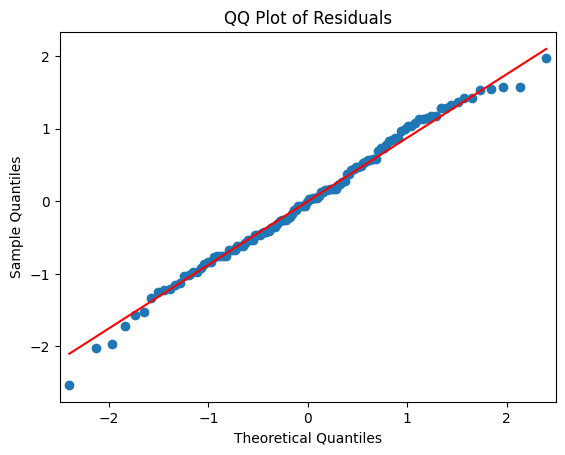

Shapiro-Wilk Test Statistic: 0.9912132000918904
Shapiro-Wilk p-value: 0.6465112757958724
Residuals are approximately normally distributed.


In [4]:
## Question 7 Code ##

## Import Relevant Libraries ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats

## Build Full Factorial ANOVA Model ##
model = ols('Satisfaction ~ Protein * Salsa * Potatoes', data=burritos).fit()

## Extract Residuals ##
residuals = model.resid

## Generate QQ Plot for Residuals ##
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

## Perform Shapiro-Wilk Test for Normality ##
shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)

if shapiro_test.pvalue > 0.05:
    print("Residuals are approximately normally distributed.")
else:
    print("Residuals are not approximately normally distributed.")

Looking at the QQ-plot of the model residuals, the points generally follow the diagonal reference line, with only slight deviations in the tails. This provides visual support for the normality assumption.

The Shapiro-Wilk test also supports this conclusion. The test produced a statistic of $W = 0.991$ with a p-value of $p = 0.647$. Since the p-value is greater than the threshold $\alpha = 0.05$, we **fail to reject the null hypothesis of normality**.

Overall, both the visual method and the formal testing method provide support that the residuals are approximately normally distributed.


8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

**Answer:**

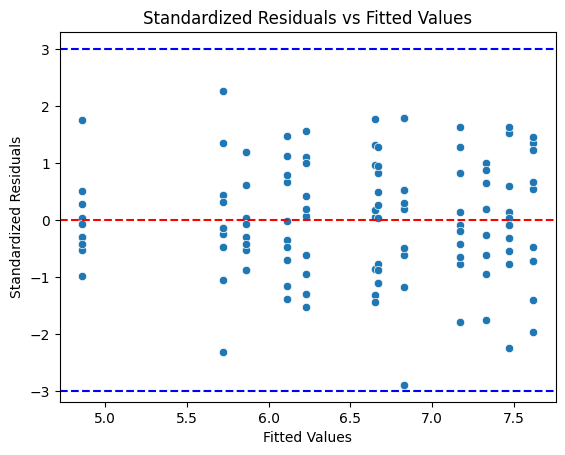

Breusch-Pagan Test Statistic: 8.62394660642261
Breusch-Pagan p-value: 0.656559099121756
Residuals exhibit constant variance.


In [6]:
## Question 8 Code ##
## Import Statsmodels ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Get Standardized Residuals ##
standardized_residuals = model.get_influence().resid_studentized_internal

## Get Fitted Values ##
fitted_values = model.fittedvalues

## Generate Standardized Residuals vs Fitted Values Plot ##
sns.scatterplot(x=fitted_values, y=standardized_residuals)

plt.axhline(0, color='red', linestyle='--')
plt.axhline(3, color='blue', linestyle='--')
plt.axhline(-3, color='blue', linestyle='--')

plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## Perform Breusch-Pagan Test for Homoscedasticity ##
bp_test = het_breuschpagan(model.resid, model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])
print("Breusch-Pagan p-value:", bp_test[1])

if bp_test[1] > 0.05:
    print("Residuals exhibit constant variance.")
else:
    print("Residuals exhibit non-constant variance.")

Looking at the scatterplot of standardized residuals versus fitted values, the residuals appear to be reasonably scattered around zero with no clear systematic pattern. In addition, no points exceed +3 or -3, suggesting no strong evidence of extreme outliers. The spread of the residuals also appears roughly similar across the fitted values, which provides visual support for the constant variance assumption.

The Breusch-Pagan test also supports this conclusion. The test produced a statistic of $BP = 8.624$ with an associated p-value of $p = 0.657$. Since this p-value is greater than the typically used threshold of $\alpha = 0.05$, we **fail to reject the null hypothesis of constant variance**.

Overall, both the visual method and the testing method provide support for the assumption of homogeneity of variance being reasonably met.


9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

**Answer:**

In [7]:
## Question 9 Code ##
## Generate ANOVA Table ##
anova_table = sm.stats.anova_lm(model, typ=1)

## Add Significance Column ##
anova_table["Significant"] = anova_table["PR(>F)"] < 0.05

## Print Results ##
print(anova_table)

                           df     sum_sq    mean_sq          F        PR(>F)  \
Protein                   2.0  36.147167  18.073583  21.193779  1.719650e-08   
Salsa                     1.0  26.885333  26.885333  31.526775  1.541578e-07   
Potatoes                  1.0   5.208333   5.208333   6.107492  1.502332e-02   
Protein:Salsa             2.0   0.383167   0.191583   0.224658  7.991617e-01   
Protein:Potatoes          2.0   2.606167   1.303083   1.528046  2.216124e-01   
Salsa:Potatoes            1.0   1.976333   1.976333   2.317524  1.308461e-01   
Protein:Salsa:Potatoes    2.0   0.828167   0.414083   0.485570  6.166832e-01   
Residual                108.0  92.100000   0.852778        NaN           NaN   

                        Significant  
Protein                        True  
Salsa                          True  
Potatoes                       True  
Protein:Salsa                 False  
Protein:Potatoes              False  
Salsa:Potatoes                False  
Protein:Salsa

Based on the ANOVA table, the **main effects** for **Protein**, **Salsa**, and **Potatoes** were statistically significant.

* **Protein:** $F(2,108) = 21.19$, $p < 0.001$
* **Salsa:** $F(1,108) = 31.53$, $p < 0.001$
* **Potatoes:** $F(1,108) = 6.11$, $p = 0.015$

This indicates that the data provide statistical support for the **alternative hypotheses** for the **main effects**. In other words, mean satisfaction ratings differ based on Protein, Salsa, and Potatoes.

For the **interaction effects**, none were statistically significant:

* **Protein x Salsa:** $F(2,108) = 0.22$, $p = 0.799$
* **Protein x Potatoes:** $F(2,108) = 1.53$, $p = 0.216$
* **Salsa x Potatoes:** $F(1,108) = 2.32$, $p = 0.131$
* **Protein x Salsa x Potatoes:** $F(2,108) = 0.49$, $p = 0.617$

This suggests that the data more strongly support the **null hypotheses** for the **interaction effects**. Practically, the effects of Protein, Salsa, and Potatoes appear to influence satisfaction ratings mostly independently rather than depending strongly on one another.


10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

**Answer:**

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo   0.1575 0.7824  -0.402   0.717  False
  Bacon Sausage  -1.0775    0.0  -1.637  -0.518   True
Chorizo Sausage   -1.235    0.0 -1.7945 -0.6755   True
------------------------------------------------------


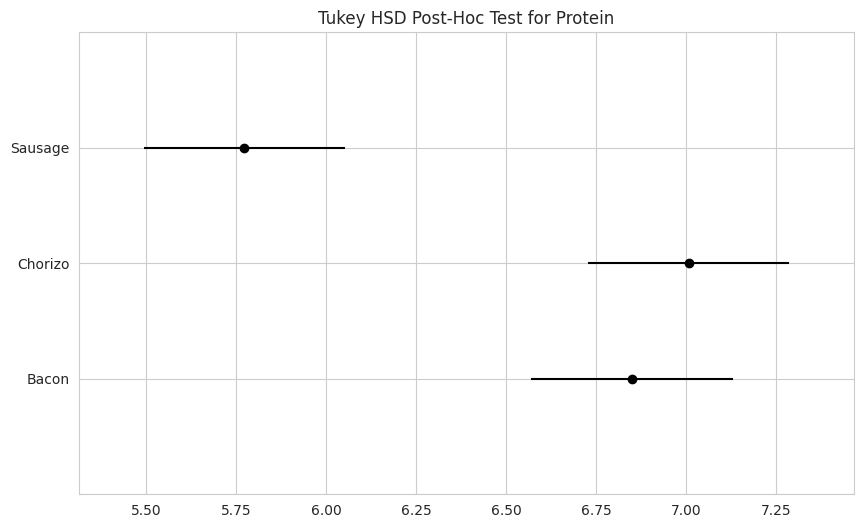

In [18]:
## Question 10 Code ##

## Import Tukey HSD ##
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Tukey HSD for Protein since Protein is significant and has 3 levels ##
tukey_protein = pairwise_tukeyhsd(
    endog=burritos["Satisfaction"],
    groups=burritos["Protein"],
    alpha=0.05
)

print(tukey_protein)

## Visualization ##
tukey_protein.plot_simultaneous()
plt.title("Tukey HSD Post-Hoc Test for Protein")
plt.show()

Since the **interaction effects** were **not statistically significant**, post-hoc testing for interaction combinations was not necessary.

However, **Protein** was **statistically significant** and has **three levels**, so Tukey's HSD was used to compare the Protein levels. The results showed that **Sausage** had significantly lower satisfaction ratings than both Bacon and Chorizo, while **Bacon** and **Chorizo** were not significantly different from each other.

Since **Salsa** and **Potatoes** each have **only two levels**, post-hoc testing was not necessary for those factors.

11. Calculate and interpret partial $\eta^2$ for the main effects.

**Answer:**

In [10]:
## Question 11 Code ##
## Load pingouin ##
# !pip install pingouin
import pingouin as pg

## Fit ANOVA with pingouin ##
mod_p = pg.anova(
    dv='Satisfaction',
    between=["Protein", "Salsa", "Potatoes"],
    data=burritos,
    effsize="np2"
).round(4)

print(mod_p[["Source", "np2"]])

                       Source     np2
0                     Protein  0.2819
1                       Salsa  0.2260
2                    Potatoes  0.0535
3             Protein * Salsa  0.0041
4          Protein * Potatoes  0.0275
5            Salsa * Potatoes  0.0210
6  Protein * Salsa * Potatoes  0.0089
7                    Residual     NaN


The partial $\eta^2$ values show that **Protein** had the largest effect on satisfaction ratings, with $\eta_p^2 = 0.2819$. This means Protein explained about **28.19%** of the variation in satisfaction after accounting for the other factors.

**Salsa** also had a large effect, with $\eta_p^2 = 0.2260$, meaning it explained about **22.60%** of the variation in satisfaction.

**Potatoes** had a smaller effect, with $\eta_p^2 = 0.0535$, meaning it explained about **5.35%** of the variation in satisfaction.

Overall, Protein appears to be the most important main effect, followed by Salsa. Potatoes was statistically significant, but its practical effect was smaller compared to Protein and Salsa.


12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

**Answer:** **Overall Conclusion:**
Overall, this experiment was performed to determine which burrito ingredient combination leads to higher customer satisfaction ratings. The results indicated that **Protein**, **Salsa**, and **Potatoes** all had statistically significant main effects. However, none of the interaction effects were statistically significant, suggesting that these factors mostly influenced satisfaction independently.

**Menu Recommendation:**
Based on the results, I would recommend offering **Chorizo + Mild salsa + Potatoes** as a regular menu option. Chorizo and Bacon had higher satisfaction ratings than Sausage, Mild salsa performed better than Hot salsa, and burritos with Potatoes had slightly higher ratings. Since the potato effect was statistically significant but smaller practically, **Chorizo + Mild salsa without Potatoes** could also be considered as an additional option.

**Limitations:**
Some limitations include the subjective nature of satisfaction ratings and possible differences in customer preferences, spice tolerance, hunger level, and dietary habits. Burrito preparation differences, such as portion size, temperature, or ingredient freshness, may also have influenced ratings.

**Future Improvements:**
Future experiments could include more participants, better control over burrito preparation, and randomization of tasting order to reduce bias or taste fatigue. It may also be useful to test additional ingredients and include cost or sales data before making final menu decisions.

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

**Answer:** The objective of this experiment is to determine the optimal combination of **truck location**, **timing**, and **marketing strategy** that maximizes daily sales for Buster's Breakfast Burritos. Specifically, the experiment examines whether setting up at a brewery or university, operating on a weekday or weekend, and using independent or partnership marketing affects the total sales amount.

2. Specify the outcome variable and how it is measured.

**Answer:** The outcome variable is **Sales**, measured as the total daily sales amount for Buster's Breakfast Burritos under each experimental condition. This is a **quantitative, continuous variable**.

3. Specify the independent variables. What lurking variables may be present?

**Answer:** The independent variables in this experiment are:

* **Location (A):** Brewery vs. University
* **Timing (B):** Weekday vs. Weekend
* **Marketing (C):** Independent vs. Partnership

These are all **categorical** treatment factors with **two levels each**.

Possible lurking variables:

* Competing food options nearby
* Differences in pricing, promotions, or menu availability
* Foot traffic at the time of operation
* Customer preferences at each location
* Time of day the truck is operating

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

**Answer:** A fractional factorial design is appropriate here because the experiment involves multiple factors, but the goal is to be more efficient with time and resources. Instead of testing all $2^3 = 8$ possible combinations, the $2^{3-1}$ design uses only 4 treatment combinations while still providing useful information about the main effects.

The main advantage is that it reduces the number of runs, saving time, money, and effort. The main disadvantage is that some effects may be aliased or confounded, meaning it can be difficult to separate certain main effects from interaction effects.

5. State the sets of null and alternative hypotheses for this experiment.

**Answer:**
$$
H_{0A}: \mu_{A+} = \mu_{A-}
$$

$$
H_{1A}: \mu_{A+} \ne \mu_{A-}
$$

$$
H_{0B}: \mu_{B+} = \mu_{B-}
$$

$$
H_{1B}: \mu_{B+} \ne \mu_{B-}
$$

$$
H_{0C}: \mu_{C+} = \mu_{C-}
$$

$$
H_{1C}: \mu_{C+} \ne \mu_{C-}
$$

Where:

- \(A\) = Location  
- \(B\) = Timing  
- \(C\) = Marketing

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

**Answer:**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   24 non-null     object 
 1   Timing     24 non-null     object 
 2   Marketing  24 non-null     object 
 3   Sales      24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 20
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   12 non-null     object 
 1   Timing     12 non-null     object 
 2   Marketing  12 non-null     object 
 3   Sales      12 non-null     float64
 4   Effect     12 non-null     object 
dtypes: float64(1), object(4)
memory usage: 576.0+ bytes
None
Location Stats:
                    mean         std
Location                           
Brewery     1114.268333  342.245452
University   936.148333  136.669

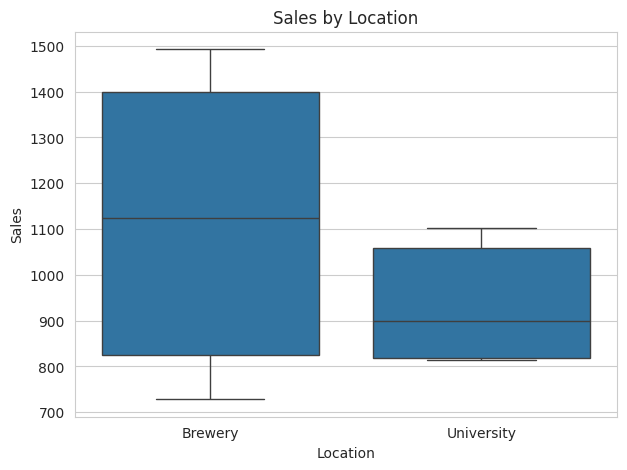

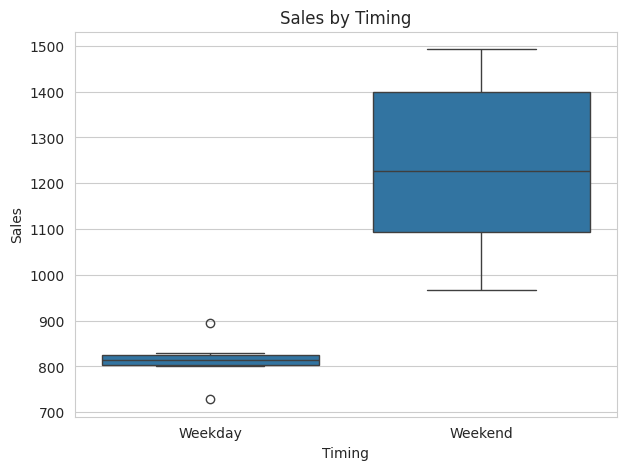

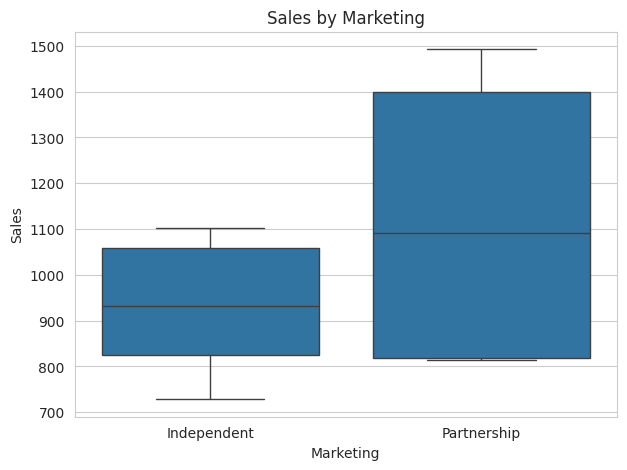

In [19]:
## Question 6 Code ##

## Import necessary libraries ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Read the data ##
sales_data = pd.read_excel("Busters Burrito Sales.xlsx")

## Data Integrity Check for full uploaded data ##
print(sales_data.info())

## Add Effect Column based on the 2^(3-1) fractional factorial design table ##
## A = Location, B = Timing, C = Marketing ##
## one = A-B-C-, ac = A+B-C+, bc = A-B+C+, ab = A+B+C- ##

sales_data["Effect"] = np.select(
    [
        (sales_data["Location"] == "Brewery") &
        (sales_data["Timing"] == "Weekday") &
        (sales_data["Marketing"] == "Independent"),

        (sales_data["Location"] == "University") &
        (sales_data["Timing"] == "Weekday") &
        (sales_data["Marketing"] == "Partnership"),

        (sales_data["Location"] == "Brewery") &
        (sales_data["Timing"] == "Weekend") &
        (sales_data["Marketing"] == "Partnership"),

        (sales_data["Location"] == "University") &
        (sales_data["Timing"] == "Weekend") &
        (sales_data["Marketing"] == "Independent")
    ],
    ["one", "ac", "bc", "ab"],
    default="other"
)

## Keep only the four runs from the fractional factorial design ##
sales_frac = sales_data[sales_data["Effect"] != "other"].copy()

## Data Integrity Check for fractional factorial data ##
print(sales_frac.info())

## Exploratory Data Analysis ##

## Main Effects ##
location_stats = sales_frac.groupby("Location")["Sales"].agg(["mean", "std"])
timing_stats = sales_frac.groupby("Timing")["Sales"].agg(["mean", "std"])
marketing_stats = sales_frac.groupby("Marketing")["Sales"].agg(["mean", "std"])

## Print Main Effect Summary Statistics ##
print("Location Stats:\n", location_stats)
print("\nTiming Stats:\n", timing_stats)
print("\nMarketing Stats:\n", marketing_stats)

## Treatment Combination Summary ##
combo_stats = sales_frac.groupby(
    ["Effect", "Location", "Timing", "Marketing"]
)["Sales"].agg(["mean", "std"])

print("\nLocation, Timing, and Marketing Stats:\n", combo_stats)

## Generate Boxplots for Main Effects ##
sns.set_style("whitegrid")

## Location ##
plt.figure(figsize=(7, 5))
sns.boxplot(x="Location", y="Sales", data=sales_frac)
plt.title("Sales by Location")
plt.xlabel("Location")
plt.ylabel("Sales")
plt.show()

## Timing ##
plt.figure(figsize=(7, 5))
sns.boxplot(x="Timing", y="Sales", data=sales_frac)
plt.title("Sales by Timing")
plt.xlabel("Timing")
plt.ylabel("Sales")
plt.show()

## Marketing ##
plt.figure(figsize=(7, 5))
sns.boxplot(x="Marketing", y="Sales", data=sales_frac)
plt.title("Sales by Marketing")
plt.xlabel("Marketing")
plt.ylabel("Sales")
plt.show()

Based on the descriptive analyses, the results appear to provide the strongest support for the **alternative hypothesis for Timing**.

* For **Location**, Brewery had a higher mean sales amount than University, with means of about **1114.27** and **936.15**, respectively. The difference is about **178.12**, which is less than the average standard deviation of about **239.46**. This provides some support for $H_{1A}$, but not overly strong evidence.

* For **Timing**, Weekend had a much higher mean sales amount than Weekday, with means of about **1236.67** and **813.75**, respectively. The difference is about **422.92**, which is well above the average standard deviation of about **132.46**. This provides strong descriptive evidence in favor of $H_{1B}$.

* For **Marketing**, Partnership had a higher mean sales amount than Independent marketing, with means of about **1119.75** and **930.67**, respectively. The difference is about **189.08**, which is less than the average standard deviation of about **241.98**. This provides some support for $H_{1C}$, but the evidence is not as strong as Timing.

The boxplots show similar information. Weekend sales appear clearly higher than Weekday sales, while Brewery and Partnership also appear to have higher sales but with more overlap between groups. Overall, the exploratory analysis provides the strongest support for **Timing**, followed by **Marketing** and **Location**.


7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

**Answer:** Given the defining relation:

$$
I = ABC
$$

the aliasing structure is:

$$
A = BC
$$

$$
B = AC
$$

$$
C = AB
$$

Where:

* (A) = Location
* (B) = Timing
* (C) = Marketing

This means that each main effect is aliased, or confounded, with a two-way interaction. Specifically, the Location effect is confounded with the Timing × Marketing interaction, the Timing effect is confounded with the Location × Marketing interaction, and the Marketing effect is confounded with the Location × Timing interaction. Therefore, we cannot fully separate whether an observed effect is due to the main factor itself or the interaction it is aliased with. Because of this, the main effects should be interpreted cautiously.

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

**Answer:**

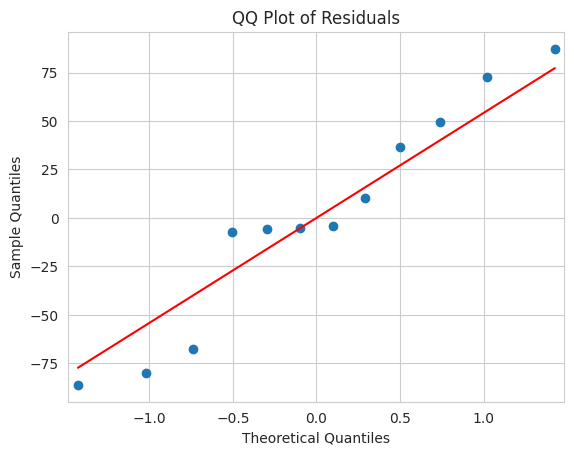

Shapiro-Wilk Test Statistic: 0.9346876759453925
Shapiro-Wilk p-value: 0.4324533858026397
Residuals are approximately normally distributed.


In [20]:
## Question 8 Code ##

## Import relevant libraries ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import matplotlib.pyplot as plt

## Fit the appropriate ANOVA model ##
sales_model = ols("Sales ~ C(Location) + C(Timing) + C(Marketing)", data=sales_frac).fit()

## Extract model residuals ##
residuals = sales_model.resid

## Assess normality ##

## QQ Plot ##
sm.qqplot(residuals, line="s")
plt.title("QQ Plot of Residuals")
plt.show()

## Shapiro-Wilk Test ##
shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Statistic:", shapiro_test.statistic)
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)

if shapiro_test.pvalue > 0.05:
    print("Residuals are approximately normally distributed.")
else:
    print("Residuals are not approximately normally distributed.")

Looking at the QQ-plot of the model residuals, the points generally follow the diagonal reference line, although there are some noticeable deviations in the tails. Because this fractional factorial design has a small sample size, these deviations do not appear severe enough to strongly suggest non-normality.

The Shapiro-Wilk test also supports this conclusion. The test produced a statistic of $W = 0.935$ with a p-value of $p = 0.432$. Since the p-value is greater than the typically used threshold of $\alpha = 0.05$, we **fail to reject the null hypothesis of normality**.

Overall, both the visual method and the testing method provide support that the **residuals are approximately normally distributed**.


9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

**Answer:**

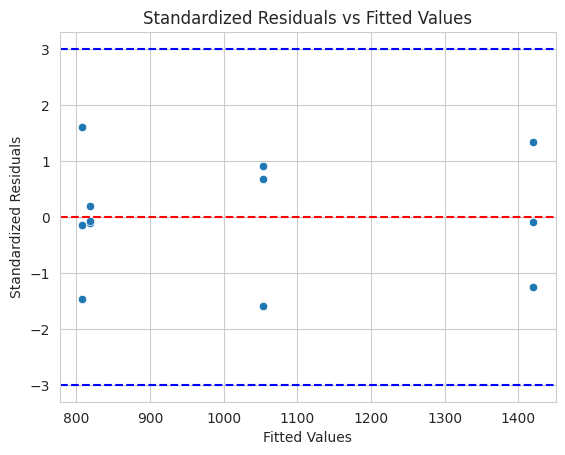

Breusch-Pagan Test Statistic: 4.1034964203964
Breusch-Pagan p-value: 0.2505030774019734
Residuals exhibit constant variance.


In [21]:
## Question 9 Code ##

## Import Breusch-Pagan Test ##
from statsmodels.stats.diagnostic import het_breuschpagan

## Get standardized residuals ##
standardized_residuals = sales_model.get_influence().resid_studentized_internal

## Get fitted values ##
fitted_values = sales_model.fittedvalues

## Generate standardized residuals vs fitted values plot ##
sns.scatterplot(x=fitted_values, y=standardized_residuals)

plt.axhline(0, color="red", linestyle="--")
plt.axhline(3, color="blue", linestyle="--")
plt.axhline(-3, color="blue", linestyle="--")

plt.title("Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## Breusch-Pagan Test ##
bp_test = het_breuschpagan(sales_model.resid, sales_model.model.exog)

print("Breusch-Pagan Test Statistic:", bp_test[0])
print("Breusch-Pagan p-value:", bp_test[1])

if bp_test[1] > 0.05:
    print("Residuals exhibit constant variance.")
else:
    print("Residuals exhibit non-constant variance.")

Looking at the scatterplot of standardized residuals versus fitted values, the residuals appear to be reasonably scattered around zero with no clear systematic pattern. Also, no points are greater than +3 or less than -3, suggesting no obvious evidence of extreme outliers. The spread of the residuals appears reasonably consistent across the fitted values, which provides support for the constant variance assumption.

The Breusch-Pagan test also supports this conclusion. The test produced a statistic of $BP = 4.103$ with an associated p-value of $p = 0.251$. Since the p-value is greater than the typically used threshold of $\alpha = 0.05$, we **fail to reject the null hypothesis of constant variance**.

Overall, both the visual method and the testing method provide support that the **homogeneity of variance assumption is reasonably met**.


10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

**Answer:**

In [22]:
## Question 10 Code ##

## Generate ANOVA Table ##
anova_table_sales = sm.stats.anova_lm(sales_model, typ=1)

## Add Significance Column ##
anova_table_sales["Significant"] = anova_table_sales["PR(>F)"] < 0.05

## Print Results ##
print(anova_table_sales)

               df         sum_sq        mean_sq           F    PR(>F)  \
C(Location)   1.0   95180.203200   95180.203200   21.620251  0.001645   
C(Timing)     1.0  536583.979200  536583.979200  121.885432  0.000004   
C(Marketing)  1.0  107249.957633  107249.957633   24.361904  0.001141   
Residual      8.0   35218.908133    4402.363517         NaN       NaN   

              Significant  
C(Location)          True  
C(Timing)            True  
C(Marketing)         True  
Residual            False  


From the ANOVA table, all 3 main effects were statistically significant:

* **Location:** $F(1,8) = 21.62$, $p = 0.002$
* **Timing:** $F(1,8) = 121.89$, $p < 0.001$
* **Marketing:** $F(1,8) = 24.36$, $p = 0.001$

This indicates that the data more strongly support the **alternative hypotheses for all 3 main effects**. In other words, mean sales appear to differ based on **Location**, **Timing**, and **Marketing**.

In other words, sales were higher for **Brewery** compared to University, **Weekend** compared to Weekday, and **Partnership** marketing compared to Independent marketing.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

**Answer:**

In [24]:
## Question 11 Code ##

## Group the Data by the Effect column and pivot from long to wide ##
df = sales_frac.groupby("Effect", as_index=False)["Sales"].mean()

## Now we want to pivot the DataFrame from long to wide format
## so that each effect is a separate column ##
df = df.pivot_table(index=None, columns="Effect", values="Sales").reset_index(drop=True)

## Extract factor columns for easier use ##
one = df["one"]
ab = df["ab"]
ac = df["ac"]
bc = df["bc"]

## Compute factor estimates ##
df2 = pd.DataFrame({
    "A": 0.5 * (-one + ab + ac - bc),
    "B": 0.5 * (-one + ab - ac + bc),
    "C": 0.5 * (-one - ab + ac + bc)
})

print(df2)

        A       B           C
0 -178.12  422.92  189.076667


The estimated main effects were:

* **A: Location = -178.12**
  This indicates that moving from Brewery to University is associated with a decrease in average sales of about **178.12**. Since the value is negative, Brewery appears to perform better than University.

* **B: Timing = 422.92**
  This indicates that moving from Weekday to Weekend is associated with an increase in average sales of about **422.92**. This is the largest effect, suggesting that Timing is the most important factor.

* **C: Marketing = 189.08**
  This indicates that moving from Independent marketing to Partnership marketing is associated with an increase in average sales of about **189.08**.

Overall, **Timing** appears to be the most important factor for sales, followed by **Marketing**, and then **Location**.

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

**Answer:**

In [17]:
## Question 12 Code ##

## Fit ANOVA with pingouin using the fractional factorial data ##
m_sales_pg = pg.anova(
    data=sales_frac,
    dv="Sales",
    between=["Location", "Timing", "Marketing"],
    effsize="np2"
).round(4)

## Print partial eta squared values for the main effects ##
print(m_sales_pg[["Source", "np2"]][0:3])

      Source     np2
0   Location  0.7299
1     Timing  0.9384
2  Marketing  0.7528


The partial $\eta^2$ values for the main effects were all quite large:

* **Location:** $\eta_p^2 = 0.7299$
* **Timing:** $\eta_p^2 = 0.9384$
* **Marketing:** $\eta_p^2 = 0.7528$

These results suggest that all three factors explain a large portion of the variation in **Sales**. **Timing** appears to be the most important factor, accounting for about **93.84%** of the variation in sales after accounting for the other factors. This aligns with the earlier main effect estimate showing that Weekend sales were much higher than Weekday sales.

**Marketing** is the second most important effect, followed closely by **Location**. Overall, the results suggest that Timing has the strongest practical impact on sales, but Marketing and Location also appear to be important.

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

**Answer:** **Overall Conclusion:**
Overall, this experiment was performed to determine which combination of **Location**, **Timing**, and **Marketing** leads to higher sales for Buster's Breakfast Burritos. The results showed that all three main effects were statistically significant, with **Timing** having the strongest effect. Sales were higher on **Weekends**, with **Partnership** marketing, and at the **Brewery** location.

**Recommendation:**
Based on the main effect estimates and treatment combination means, I would recommend the **Brewery + Weekend + Partnership** combination. This combination had the highest observed mean sales among the fractional factorial runs and aligns with the strongest practical findings.

**Limitations:**
A key limitation is that this is a $2^{3-1}$ fractional factorial design, so main effects are aliased with two-way interactions. Therefore, the effects should be interpreted cautiously. Sales may also be influenced by outside factors such as weather, local events, foot traffic, competing vendors, and customer preferences.

**Future Directions:**
Future studies could use a full $2^3$ factorial design to separate main effects from interaction effects. It would also be helpful to collect data across more days and locations to confirm whether the recommended combination consistently produces the highest sales.

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

**Answer:** To de-alias main effects and interactions in a fractional factorial design, we can run a second experiment using the opposite sign of the defining relation. For example, if the original design uses $I = +ABC$, then running the opposite fraction with $I = -ABC$ allows us to separate the main effects from the two-way interactions they were originally aliased with.

This is important because aliasing means we cannot tell whether an observed effect is due to the main factor itself or the interaction it is confounded with. However, this may not always be feasible because it requires additional experimental runs, which increases time, cost, and resources.

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

**Answer:** Specifying the characteristics of an experiment before analysis is good practice because it makes sure we understand the study before applying statistical tests. Identifying the objective, outcome variable, independent variables, blocking factors, lurking variables, and hypotheses helps us choose the correct experimental design and model. It also helps avoid misleading conclusions by making clear what is being tested, what is being controlled for, and what outside factors may still affect the results. In short, it keeps the analysis organized, appropriate, and tied back to the real research question.

3. What is the difference between a fixed effect and a random effect?

**Answer:** A **fixed effect** is a factor whose levels are specifically chosen and are of direct interest in the experiment. For example, if a study compares specific treatment types, machine settings, or product designs, those factors would usually be fixed effects.

A **random effect** is a factor whose levels represent a random sample from a larger population of possible levels. For example, if a study includes a sample of participants, classrooms, operators, or locations, those may be treated as random effects when the goal is to account for variation across those groups rather than compare each specific group directly.

In short, fixed effects are the factors we mainly want to compare, while random effects represent broader sources of variability.

4. What is the most important thing you learned in this class?

**Answer:** The most important thing I learned in this class is that choosing the correct experimental design is just as important as running the statistical test. Before analyzing the data, we need to clearly understand the objective, outcome variable, treatment factors, possible nuisance variables, and whether the design should be completely randomized, blocked, factorial, fractional factorial, or mixed. This helped me see that good statistical conclusions depend not only on the code, but also on how well the experiment was designed and interpreted.
